In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import gcsfs
import os

gcs = gcsfs.GCSFileSystem(token='anon')
path = 'gs://gcp-public-data-arco-era5/ar/1959-2022-6h-128x64_equiangular_with_poles_conservative.zarr/'
full_era5 = xr.open_zarr(gcs.get_mapper(path), chunks='auto')
#full_era5.to_netcdf('../data/era5_6h_128x64.nc', engine='h5netcdf')

/projekt_agmwend/home_rad/Joshua/micromamba/envs/mamba_josh/lib/python3.12/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gini' loading failed:
module 'numpy' has no attribute 'cumproduct'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


In [2]:
original_era5 = xr.open_dataset('/projekt_agmwend/data_raw/COMPEX-EC/04_ERA5/ERA5_pressure_levels/20250418.nc')
original_era5

<xarray.Dataset> Size: 197MB
Dimensions:         (valid_time: 24, pressure_level: 37, latitude: 54,
                     longitude: 79)
Coordinates:
    number          int64 8B ...
  * valid_time      (valid_time) datetime64[ns] 192B 2025-04-18 ... 2025-04-1...
  * pressure_level  (pressure_level) float64 296B 1e+03 975.0 950.0 ... 2.0 1.0
  * latitude        (latitude) float64 432B 75.08 74.83 74.58 ... 62.08 61.83
  * longitude       (longitude) float64 632B 11.76 12.01 12.26 ... 31.01 31.26
    expver          (valid_time) <U4 384B ...
Data variables: (12/13)
    cc              (valid_time, pressure_level, latitude, longitude) float32 15MB ...
    z               (valid_time, pressure_level, latitude, longitude) float32 15MB ...
    o3              (valid_time, pressure_level, latitude, longitude) float32 15MB ...
    r               (valid_time, pressure_level, latitude, longitude) float32 15MB ...
    ciwc            (valid_time, pressure_level, latitude, longitude) float32 15MB ...
    clwc            (valid_time, pressure_level, latitude, longitude) float32 15MB ...
    ...              ...
    crwc            (valid_time, pressure_level, latitude, longitude) float32 15MB ...
    cswc            (valid_time, pressure_level, latitude, longitude) float32 15MB ...
    t               (valid_time, pressure_level, latitude, longitude) float32 15MB ...
    u               (valid_time, pressure_level, latitude, longitude) float32 15MB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 15MB ...
    w               (valid_time, pressure_level, latitude, longitude) float32 15MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-11T15:20 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
full_era5

<xarray.Dataset> Size: 326GB
Dimensions:                                           (time: 92040,
                                                       longitude: 128,
                                                       latitude: 64, level: 13)
Coordinates:
  * latitude                                          (latitude) float64 512B ...
  * level                                             (level) int64 104B 50 ....
  * longitude                                         (longitude) float64 1kB ...
  * time                                              (time) datetime64[ns] 736kB ...
Data variables: (12/38)
    10m_u_component_of_wind                           (time, longitude, latitude) float32 3GB dask.array<chunksize=(40, 128, 64), meta=np.ndarray>
    10m_v_component_of_wind                           (time, longitude, latitude) float32 3GB dask.array<chunksize=(40, 128, 64), meta=np.ndarray>
    10m_wind_speed                                    (time, longitude, latitude) float32 3GB dask.array<chunksize=(40, 128, 64), meta=np.ndarray>
    2m_temperature                                    (time, longitude, latitude) float32 3GB dask.array<chunksize=(40, 128, 64), meta=np.ndarray>
    angle_of_sub_gridscale_orography                  (longitude, latitude) float32 33kB dask.array<chunksize=(128, 64), meta=np.ndarray>
    anisotropy_of_sub_gridscale_orography             (longitude, latitude) float32 33kB dask.array<chunksize=(128, 64), meta=np.ndarray>
    ...                                                ...
    type_of_high_vegetation                           (longitude, latitude) float32 33kB dask.array<chunksize=(128, 64), meta=np.ndarray>
    type_of_low_vegetation                            (longitude, latitude) float32 33kB dask.array<chunksize=(128, 64), meta=np.ndarray>
    u_component_of_wind                               (time, level, longitude, latitude) float32 39GB dask.array<chunksize=(40, 13, 128, 64), meta=np.ndarray>
    v_component_of_wind                               (time, level, longitude, latitude) float32 39GB dask.array<chunksize=(40, 13, 128, 64), meta=np.ndarray>
    vertical_velocity                                 (time, level, longitude, latitude) float32 39GB dask.array<chunksize=(40, 13, 128, 64), meta=np.ndarray>
    wind_speed                                        (time, level, longitude, latitude) float32 39GB dask.array<chunksize=(40, 13, 128, 64), meta=np.ndarray>

In [4]:
era5_to_sim = full_era5.rename({
    'sea_surface_temperature': 'surface_temperature',
    'temperature': 't',
    'specific_humidity': 'q',
    'geopotential': 'z',
    'level': 'pressure_level',
    'time' : 'valid_time',
})



### manually add ozone profile if not present
if 'o3' not in era5_to_sim.data_vars:
    # Use a constant profile for ozone, e.g., 300 DU
    # Convert DU to number density (1 DU = 2.687e19 molecules/m^2)
    # Assume a standard atmosphere for conversion
    altitude_km = era5_to_sim['z'] / 1000.0  # Convert geopotential height to km
    o3_profile = xr.DataArray(
        data=300e-6 * 2.687e19 * np.exp(-altitude_km / 8.5),  # Example exponential decay
        dims=era5_to_sim['z'].dims,
        coords=era5_to_sim['z'].coords,
        name='o3'
    )
    era5_to_sim = era5_to_sim.assign(o3=o3_profile)


In [ ]:
# Import PyRadtran components using NEW IO system
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd

# Load the configuration from the YAML file
config_path = Path('../config/thermal_config.yaml')
import logging
# change to "DEBUG" if you want to see more output
logging.getLogger('pyradtran').setLevel(logging.DEBUG)

N_timesteps = 10

# stationary simulation at constant altitude, latitude, and longitude but with varying time
ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2020-04-04T08:00:00', periods=N_timesteps, freq='h'),
        'latitude' : ('time', [61.0] * N_timesteps),
        'longitude' : ('time', [22.0] * N_timesteps),
        'altitude' : ('altitude', np.arange(0, 100, 10)),
    }
)

# load the ERA5 data for the specified space and time // this didn't make it faster...
ds_era5_local = era5_to_sim.sel(
    latitude=ds['latitude'],
    longitude=ds['longitude'],
    valid_time=ds['time'],
    method='nearest'
).load()

In [6]:
ds_sim = ds.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    #save_to_file=True,
    era5_atmosphere=era5_to_sim,
)

2025-07-22 00:12:32,421 - pyradtran.interface - INFO - ERA5 atmosphere dataset validated with 13 pressure levels
2025-07-22 00:12:32,422 - pyradtran.interface - INFO - Altitude found as coordinate - using 1 levels for zout: [10]
2025-07-22 00:12:32,424 - pyradtran.interface - INFO - Auto-generating output path: work/xarray_example_20250722_001232.nc
2025-07-22 00:12:32,424 - pyradtran.interface - INFO - Creating ERA5 atmosphere files for simulation points...


2025-07-22 00:12:32,471 - pyradtran.io_old - INFO - 'co2' variable not found in dataset. Using constant 420 ppmv.
2025-07-22 00:12:32,472 - pyradtran.io_old - INFO - 'no2' variable not found in dataset. Using zero concentration.
2025-07-22 00:12:42,708 - pyradtran.io_old - INFO - Successfully created libRadtran atmosphere file at: work/era5_atmospheres/era5_atm_20200404_080000_61.00_22.00.dat
2025-07-22 00:12:42,710 - pyradtran.interface - DEBUG - Created ERA5 atmosphere file for 20200404_080000_61.00_22.00: work/era5_atmospheres/era5_atm_20200404_080000_61.00_22.00.dat
2025-07-22 00:12:42,758 - pyradtran.io_old - INFO - 'co2' variable not found in dataset. Using constant 420 ppmv.
2025-07-22 00:12:42,759 - pyradtran.io_old - INFO - 'no2' variable not found in dataset. Using zero concentration.
2025-07-22 00:12:52,917 - pyradtran.io_old - INFO - Successfully created libRadtran atmosphere file at: work/era5_atmospheres/era5_atm_20200404_090000_61.00_22.00.dat
2025-07-22 00:12:52,918 - p

In [7]:
### compare era5 radiation with pyradtran simulations


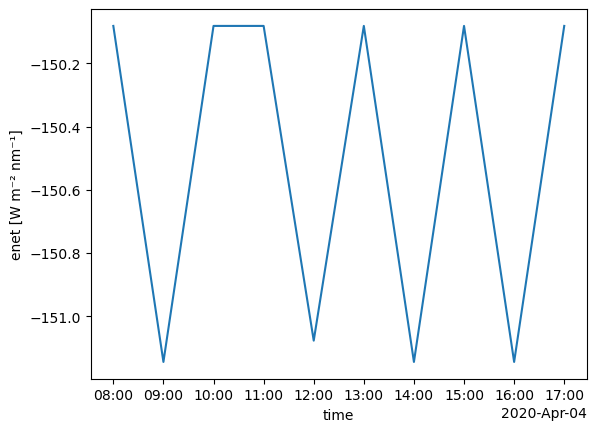

In [14]:
ds_sim['enet'].plot()

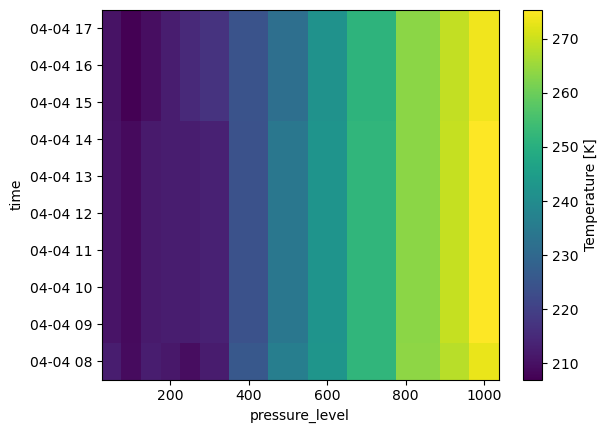

In [15]:
ds_era5_local.t.plot()

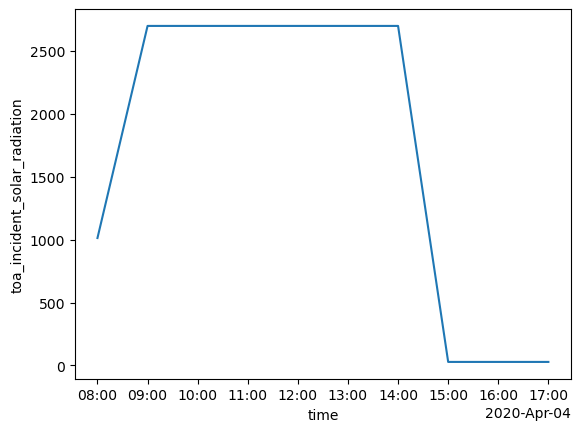

In [10]:
(ds_era5_local['toa_incident_solar_radiation'] / 1000).plot()